In [71]:
import pandas as pd
#from pymol import cmd
import py3Dmol
import matplotlib.pyplot as plt
import seaborn as sns 
from openbabel import pybel
from rdkit import Chem
from rdkit.Chem import AllChem
import sys, os, random
import glob
from joblib import Parallel, delayed
#from tqdm import tqdm
from sklearn import metrics
from sklearn.metrics import precision_recall_curve, auc
#from cf_matrix import make_confusion_matrix
sns.set_context('talk')
import warnings
warnings.filterwarnings("ignore")
%config Completer.use_jedi = False

In [72]:
def bin_predicted_pIC50(row):
    if row['Predicted_score'] >= 0.5:
        val = 'active'
    else:
        val = "inactive"
    return val

def bin_observed_pIC50(row):
    if row['Observed_pIC50'] > 4.3:
        val = 'active'
    else:
        val = 'inactive'
    return val

# **Load data**

In [6]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_actives_docked/')
docked_sdf_active = glob.glob('mol*.sdf')
docked_sdf_active.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
docked_sdf_active

['mol_0_docked.sdf',
 'mol_1_docked.sdf',
 'mol_2_docked.sdf',
 'mol_3_docked.sdf',
 'mol_4_docked.sdf',
 'mol_5_docked.sdf',
 'mol_6_docked.sdf',
 'mol_7_docked.sdf',
 'mol_8_docked.sdf',
 'mol_9_docked.sdf',
 'mol_10_docked.sdf',
 'mol_11_docked.sdf',
 'mol_12_docked.sdf',
 'mol_13_docked.sdf',
 'mol_14_docked.sdf',
 'mol_15_docked.sdf',
 'mol_16_docked.sdf',
 'mol_17_docked.sdf',
 'mol_18_docked.sdf',
 'mol_19_docked.sdf',
 'mol_20_docked.sdf',
 'mol_21_docked.sdf',
 'mol_22_docked.sdf',
 'mol_23_docked.sdf',
 'mol_24_docked.sdf',
 'mol_25_docked.sdf',
 'mol_26_docked.sdf',
 'mol_27_docked.sdf',
 'mol_28_docked.sdf',
 'mol_29_docked.sdf',
 'mol_30_docked.sdf',
 'mol_31_docked.sdf',
 'mol_32_docked.sdf',
 'mol_33_docked.sdf',
 'mol_34_docked.sdf',
 'mol_35_docked.sdf',
 'mol_36_docked.sdf',
 'mol_37_docked.sdf',
 'mol_38_docked.sdf',
 'mol_39_docked.sdf',
 'mol_40_docked.sdf',
 'mol_41_docked.sdf',
 'mol_42_docked.sdf',
 'mol_43_docked.sdf',
 'mol_44_docked.sdf',
 'mol_45_docked.sdf'

In [8]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_decoys_docked/')
docked_sdf_dec = glob.glob('mol*.sdf')
docked_sdf_dec.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
docked_sdf_dec

['mol_0_docked.sdf',
 'mol_1_docked.sdf',
 'mol_2_docked.sdf',
 'mol_3_docked.sdf',
 'mol_4_docked.sdf',
 'mol_5_docked.sdf',
 'mol_6_docked.sdf',
 'mol_7_docked.sdf',
 'mol_8_docked.sdf',
 'mol_9_docked.sdf',
 'mol_10_docked.sdf',
 'mol_11_docked.sdf',
 'mol_12_docked.sdf',
 'mol_13_docked.sdf',
 'mol_14_docked.sdf',
 'mol_15_docked.sdf',
 'mol_16_docked.sdf',
 'mol_17_docked.sdf',
 'mol_18_docked.sdf',
 'mol_19_docked.sdf',
 'mol_20_docked.sdf',
 'mol_21_docked.sdf',
 'mol_22_docked.sdf',
 'mol_23_docked.sdf',
 'mol_24_docked.sdf',
 'mol_25_docked.sdf',
 'mol_26_docked.sdf',
 'mol_27_docked.sdf',
 'mol_28_docked.sdf',
 'mol_29_docked.sdf',
 'mol_30_docked.sdf',
 'mol_31_docked.sdf',
 'mol_32_docked.sdf',
 'mol_33_docked.sdf',
 'mol_34_docked.sdf',
 'mol_35_docked.sdf',
 'mol_36_docked.sdf',
 'mol_37_docked.sdf',
 'mol_38_docked.sdf',
 'mol_39_docked.sdf',
 'mol_40_docked.sdf',
 'mol_41_docked.sdf',
 'mol_42_docked.sdf',
 'mol_43_docked.sdf',
 'mol_44_docked.sdf',
 'mol_45_docked.sdf'

In [9]:
print(len(docked_sdf_active))
print(len(docked_sdf_dec))

147
7300


# **CNNscore**

# **TrueActives**

In [10]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_actives_docked/')
input_files = glob.glob('mol*.sdf')
input_files.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
input_files

['mol_0_docked.sdf',
 'mol_1_docked.sdf',
 'mol_2_docked.sdf',
 'mol_3_docked.sdf',
 'mol_4_docked.sdf',
 'mol_5_docked.sdf',
 'mol_6_docked.sdf',
 'mol_7_docked.sdf',
 'mol_8_docked.sdf',
 'mol_9_docked.sdf',
 'mol_10_docked.sdf',
 'mol_11_docked.sdf',
 'mol_12_docked.sdf',
 'mol_13_docked.sdf',
 'mol_14_docked.sdf',
 'mol_15_docked.sdf',
 'mol_16_docked.sdf',
 'mol_17_docked.sdf',
 'mol_18_docked.sdf',
 'mol_19_docked.sdf',
 'mol_20_docked.sdf',
 'mol_21_docked.sdf',
 'mol_22_docked.sdf',
 'mol_23_docked.sdf',
 'mol_24_docked.sdf',
 'mol_25_docked.sdf',
 'mol_26_docked.sdf',
 'mol_27_docked.sdf',
 'mol_28_docked.sdf',
 'mol_29_docked.sdf',
 'mol_30_docked.sdf',
 'mol_31_docked.sdf',
 'mol_32_docked.sdf',
 'mol_33_docked.sdf',
 'mol_34_docked.sdf',
 'mol_35_docked.sdf',
 'mol_36_docked.sdf',
 'mol_37_docked.sdf',
 'mol_38_docked.sdf',
 'mol_39_docked.sdf',
 'mol_40_docked.sdf',
 'mol_41_docked.sdf',
 'mol_42_docked.sdf',
 'mol_43_docked.sdf',
 'mol_44_docked.sdf',
 'mol_45_docked.sdf'

In [11]:
len(input_files)

147

In [12]:
out=pybel.Outputfile(filename='docked_test_true_actives.sdf',format='sdf',overwrite=True)
for input_file in input_files:
    mol=next(pybel.readfile('sdf', input_file))
    out.write(mol)

In [13]:
pwd

'/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_actives_docked'

In [14]:
!../gnina --score_only -r ../receptor.pdb -l docked_test_true_actives.sdf >& docked_test_true_actives_cnn.csv

In [15]:
!grep 'CNNscore' docked_test_true_actives_cnn.csv >& test_true_actives_cnn.csv

In [16]:
!grep 'CNNaffinity' docked_test_true_actives_cnn.csv >& test_true_actives_cnn_affinity.csv

# **Decoys**

In [17]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_decoys_docked/')
input_files = glob.glob('mol*.sdf')
input_files.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
input_files

['mol_0_docked.sdf',
 'mol_1_docked.sdf',
 'mol_2_docked.sdf',
 'mol_3_docked.sdf',
 'mol_4_docked.sdf',
 'mol_5_docked.sdf',
 'mol_6_docked.sdf',
 'mol_7_docked.sdf',
 'mol_8_docked.sdf',
 'mol_9_docked.sdf',
 'mol_10_docked.sdf',
 'mol_11_docked.sdf',
 'mol_12_docked.sdf',
 'mol_13_docked.sdf',
 'mol_14_docked.sdf',
 'mol_15_docked.sdf',
 'mol_16_docked.sdf',
 'mol_17_docked.sdf',
 'mol_18_docked.sdf',
 'mol_19_docked.sdf',
 'mol_20_docked.sdf',
 'mol_21_docked.sdf',
 'mol_22_docked.sdf',
 'mol_23_docked.sdf',
 'mol_24_docked.sdf',
 'mol_25_docked.sdf',
 'mol_26_docked.sdf',
 'mol_27_docked.sdf',
 'mol_28_docked.sdf',
 'mol_29_docked.sdf',
 'mol_30_docked.sdf',
 'mol_31_docked.sdf',
 'mol_32_docked.sdf',
 'mol_33_docked.sdf',
 'mol_34_docked.sdf',
 'mol_35_docked.sdf',
 'mol_36_docked.sdf',
 'mol_37_docked.sdf',
 'mol_38_docked.sdf',
 'mol_39_docked.sdf',
 'mol_40_docked.sdf',
 'mol_41_docked.sdf',
 'mol_42_docked.sdf',
 'mol_43_docked.sdf',
 'mol_44_docked.sdf',
 'mol_45_docked.sdf'

In [18]:
len(input_files)

7300

In [19]:
out=pybel.Outputfile(filename='docked_decoys.sdf',format='sdf',overwrite=True)
for input_file in input_files:
    mol=next(pybel.readfile('sdf', input_file))
    out.write(mol)

*** Open Babel Error  in TetStereoToWedgeHash
  Failed to set stereochemistry as unable to find an available bond


In [20]:
!../gnina --score_only -r ../receptor.pdb -l docked_decoys.sdf >& docked_decoys_cnn.csv

In [21]:
!grep 'CNNscore' docked_decoys_cnn.csv >& test_decoys_cnn_cnn.csv

In [22]:
!grep 'CNNaffinity' docked_decoys_cnn.csv >& test_decoys_cnn_affinity.csv

# **RFScoreV2**

# **Actives**

In [23]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_actives_docked/')

In [24]:
ls

docked_test_true_actives_cnn.csv  mol_35_docked.sdf
docked_test_true_actives.sdf      mol_36_docked.sdf
mol_0_docked.sdf                  mol_37_docked.sdf
mol_100_docked.sdf                mol_38_docked.sdf
mol_101_docked.sdf                mol_39_docked.sdf
mol_102_docked.sdf                mol_3_docked.sdf
mol_103_docked.sdf                mol_40_docked.sdf
mol_104_docked.sdf                mol_41_docked.sdf
mol_105_docked.sdf                mol_42_docked.sdf
mol_106_docked.sdf                mol_43_docked.sdf
mol_107_docked.sdf                mol_44_docked.sdf
mol_108_docked.sdf                mol_45_docked.sdf
mol_109_docked.sdf                mol_46_docked.sdf
mol_10_docked.sdf                 mol_47_docked.sdf
mol_110_docked.sdf                mol_48_docked.sdf
mol_111_docked.sdf                mol_49_docked.sdf
mol_112_docked.sdf                mol_4_docked.sdf
mol_113_docked.sdf                mol_50_docked.sdf
mol_114_docked.sdf                mol_51_docked.sdf
mol_115_docked

In [25]:
!../rf-score-vs --receptor ../receptor.pdb docked_test_true_actives.sdf -O docked_test_true_actives_rfscore.sdf

In [26]:
!awk 'f{print;f=0} /RF/{f=1}' docked_test_true_actives_rfscore.sdf >& test_true_actives_rfscore.csv

# **Decoys**

In [27]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_decoys_docked/')

In [28]:
ls

docked_decoys_cnn.csv  mol_3190_docked.sdf  mol_5382_docked.sdf
docked_decoys.sdf      mol_3191_docked.sdf  mol_5383_docked.sdf
mol_0_docked.sdf       mol_3192_docked.sdf  mol_5384_docked.sdf
mol_1000_docked.sdf    mol_3193_docked.sdf  mol_5385_docked.sdf
mol_1001_docked.sdf    mol_3194_docked.sdf  mol_5386_docked.sdf
mol_1002_docked.sdf    mol_3195_docked.sdf  mol_5387_docked.sdf
mol_1003_docked.sdf    mol_3196_docked.sdf  mol_5388_docked.sdf
mol_1004_docked.sdf    mol_3197_docked.sdf  mol_5389_docked.sdf
mol_1005_docked.sdf    mol_3198_docked.sdf  mol_538_docked.sdf
mol_1006_docked.sdf    mol_3199_docked.sdf  mol_5390_docked.sdf
mol_1007_docked.sdf    mol_319_docked.sdf   mol_5391_docked.sdf
mol_1008_docked.sdf    mol_31_docked.sdf    mol_5392_docked.sdf
mol_1009_docked.sdf    mol_3200_docked.sdf  mol_5393_docked.sdf
mol_100_docked.sdf     mol_3201_docked.sdf  mol_5394_docked.sdf
mol_1010_docked.sdf    mol_3202_docked.sdf  mol_5395_docked.sdf
mol_1011_docked.sdf    mol_3203_docked.sd

In [29]:
!../rf-score-vs --receptor ../receptor.pdb docked_decoys.sdf -O docked_decoys_rfscore.sdf

In [30]:
!awk 'f{print;f=0} /RF/{f=1}' docked_decoys_rfscore.sdf >& docked_decoys_rfscore.csv

# **SCORCH**

# **Actives**

In [32]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_actives_docked/')
input_files = glob.glob('mol*.sdf')
input_files.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
input_files

['mol_0_docked.sdf',
 'mol_1_docked.sdf',
 'mol_2_docked.sdf',
 'mol_3_docked.sdf',
 'mol_4_docked.sdf',
 'mol_5_docked.sdf',
 'mol_6_docked.sdf',
 'mol_7_docked.sdf',
 'mol_8_docked.sdf',
 'mol_9_docked.sdf',
 'mol_10_docked.sdf',
 'mol_11_docked.sdf',
 'mol_12_docked.sdf',
 'mol_13_docked.sdf',
 'mol_14_docked.sdf',
 'mol_15_docked.sdf',
 'mol_16_docked.sdf',
 'mol_17_docked.sdf',
 'mol_18_docked.sdf',
 'mol_19_docked.sdf',
 'mol_20_docked.sdf',
 'mol_21_docked.sdf',
 'mol_22_docked.sdf',
 'mol_23_docked.sdf',
 'mol_24_docked.sdf',
 'mol_25_docked.sdf',
 'mol_26_docked.sdf',
 'mol_27_docked.sdf',
 'mol_28_docked.sdf',
 'mol_29_docked.sdf',
 'mol_30_docked.sdf',
 'mol_31_docked.sdf',
 'mol_32_docked.sdf',
 'mol_33_docked.sdf',
 'mol_34_docked.sdf',
 'mol_35_docked.sdf',
 'mol_36_docked.sdf',
 'mol_37_docked.sdf',
 'mol_38_docked.sdf',
 'mol_39_docked.sdf',
 'mol_40_docked.sdf',
 'mol_41_docked.sdf',
 'mol_42_docked.sdf',
 'mol_43_docked.sdf',
 'mol_44_docked.sdf',
 'mol_45_docked.sdf'

In [33]:
print(len(input_files))

147


In [34]:
#convert all actives molecules into pdbqt
for input_file in input_files:
    mol=next(pybel.readfile('sdf', input_file))
    out=pybel.Outputfile(filename='/home/juni/working/mettl3/notebooks/attention_score/docked_mols/pdbqt_actives_test/'+input_file[:-4]+'.pdbqt',format='pdbqt',overwrite=True)
    out.write(mol)
    out.close()

In [116]:
# for scoring open terminal and activate scorch environment, then enter the following commond
# conda activate scorch
#go to scorch directory and run the following code
# python scorch.py --receptor path-to-receptor.pdb --ligand path-to-ligand.mol2 --out path-to-output-file --threads 40
#in my case 
#python scorch.py --receptor /home/juni/working/ythdf/06_generic/receptor.pdb --ligand /home/juni/working/ythdf/06_generic/test_actives/pdbqt_actives/ --out /home/juni/working/ythdf/06_generic/test_actives/test_actives_scorch.csv --threads 40

In [ ]:
#convert all actives molecules into pdbqt
for input_file in input_files:
    mol=next(pybel.readfile('sdf', input_file))
    out=pybel.Outputfile(filename='/home/juni/working/mettl3/pdbqt_actives_test/'+input_file[:-4]+'.pdbqt',format='pdbqt',overwrite=True)
    out.write(mol)
    out.close()
# for scoring open terminal and activate scorch environment, then enter the following commond
# conda activate scorch
#go to scorch directory and run the following code
# python scorch.py --receptor path-to-receptor.pdb --ligand path-to-ligand.mol2 --out path-to-output-file --threads 40
#in my case 
#python scorch.py --receptor /home/juni/working/ythdf/06_generic/receptor.pdb --ligand /home/juni/working/ythdf/06_generic/test_actives/pdbqt_actives/ --out /home/juni/working/ythdf/06_generic/test_actives/test_actives_scorch.csv --threads 40

# **Decoys**

In [35]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_decoys_docked/')

In [36]:
input_files = glob.glob('mol*.sdf')
input_files.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
input_files

['mol_0_docked.sdf',
 'mol_1_docked.sdf',
 'mol_2_docked.sdf',
 'mol_3_docked.sdf',
 'mol_4_docked.sdf',
 'mol_5_docked.sdf',
 'mol_6_docked.sdf',
 'mol_7_docked.sdf',
 'mol_8_docked.sdf',
 'mol_9_docked.sdf',
 'mol_10_docked.sdf',
 'mol_11_docked.sdf',
 'mol_12_docked.sdf',
 'mol_13_docked.sdf',
 'mol_14_docked.sdf',
 'mol_15_docked.sdf',
 'mol_16_docked.sdf',
 'mol_17_docked.sdf',
 'mol_18_docked.sdf',
 'mol_19_docked.sdf',
 'mol_20_docked.sdf',
 'mol_21_docked.sdf',
 'mol_22_docked.sdf',
 'mol_23_docked.sdf',
 'mol_24_docked.sdf',
 'mol_25_docked.sdf',
 'mol_26_docked.sdf',
 'mol_27_docked.sdf',
 'mol_28_docked.sdf',
 'mol_29_docked.sdf',
 'mol_30_docked.sdf',
 'mol_31_docked.sdf',
 'mol_32_docked.sdf',
 'mol_33_docked.sdf',
 'mol_34_docked.sdf',
 'mol_35_docked.sdf',
 'mol_36_docked.sdf',
 'mol_37_docked.sdf',
 'mol_38_docked.sdf',
 'mol_39_docked.sdf',
 'mol_40_docked.sdf',
 'mol_41_docked.sdf',
 'mol_42_docked.sdf',
 'mol_43_docked.sdf',
 'mol_44_docked.sdf',
 'mol_45_docked.sdf'

In [37]:
print(len(input_files))

7300


In [38]:
#convert all actives molecules into pdbqt
for input_file in input_files:
    mol=next(pybel.readfile('sdf', input_file))
    out=pybel.Outputfile(filename='/home/juni/working/mettl3/notebooks/attention_score/docked_mols/pdbqt_decoys_test/'+input_file[:-4]+'.pdbqt',format='pdbqt',overwrite=True)
    out.write(mol)
    out.close()

In [ ]:
# for scoring open terminal and activate scorch environment, then enter the following commond
# conda activate scorch
#go to scorch directory and run the following code
# python scorch.py --receptor path-to-receptor.pdb --ligand path-to-ligand.mol2 --out path-to-output-file --threads 40
#in my case 
#python scorch.py --receptor /home/juni/working/ythdf/06_generic/receptor.pdb --ligand /home/juni/working/ythdf/06_generic/test_actives/pdbqt_actives/ --out /home/juni/working/ythdf/06_generic/test_actives/test_actives_scorch.csv --threads 40

# **Generate Virtual screening hits list**

In [42]:
test_deepcoy_plec = pd.read_csv('/home/juni/working/eman/revised_paper/test_deepcoy_plec_hard.csv')
test_randomdecoys_plec = pd.read_csv('/home/juni/working/eman/revised_paper/test_randomdecoys_plec_hard')

In [44]:
test_deepcoy_plec

,PLEC_0,PLEC_1,PLEC_2,PLEC_3,PLEC_4,PLEC_5,PLEC_6,PLEC_7,PLEC_8,PLEC_9,...,PLEC_4085,PLEC_4086,PLEC_4087,PLEC_4088,PLEC_4089,PLEC_4090,PLEC_4091,class,potency,index
0,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,active,4.823909,600.0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,active,5.443697,524.0
2,0,0,0,1,0,0,0,1,0,0,...,0,0,1,1,0,0,0,active,3.568636,661.0
3,0,0,0,0,0,0,0,5,0,0,...,0,0,0,0,0,0,0,active,5.721246,521.0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,active,5.193820,471.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5922,1,0,0,2,0,0,0,0,0,1,...,0,0,0,0,0,0,0,inactive,2.000000,NaN
5923,0,0,0,0,0,2,0,4,0,0,...,0,1,0,0,0,0,0,inactive,2.000000,NaN
5924,0,0,0,0,0,0,0,3,0,0,...,0,0,0,0,0,0,0,inactive,2.000000,NaN
5925,0,0,0,0,0,0,0,6,2,0,...,0,1,0,0,0,0,0,inactive,2.000000,NaN


# **Smina score**

In [39]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_actives_docked/')

In [40]:
ls

docked_test_true_actives_cnn.csv      mol_36_docked.sdf
docked_test_true_actives_rfscore.sdf  mol_37_docked.sdf
docked_test_true_actives.sdf          mol_38_docked.sdf
mol_0_docked.sdf                      mol_39_docked.sdf
mol_100_docked.sdf                    mol_3_docked.sdf
mol_101_docked.sdf                    mol_40_docked.sdf
mol_102_docked.sdf                    mol_41_docked.sdf
mol_103_docked.sdf                    mol_42_docked.sdf
mol_104_docked.sdf                    mol_43_docked.sdf
mol_105_docked.sdf                    mol_44_docked.sdf
mol_106_docked.sdf                    mol_45_docked.sdf
mol_107_docked.sdf                    mol_46_docked.sdf
mol_108_docked.sdf                    mol_47_docked.sdf
mol_109_docked.sdf                    mol_48_docked.sdf
mol_10_docked.sdf                     mol_49_docked.sdf
mol_110_docked.sdf                    mol_4_docked.sdf
mol_111_docked.sdf                    mol_50_docked.sdf
mol_112_docked.sdf                    mol_51_docke

In [41]:
# get the score from the docked poses of test set 1 actives
smina_true_active_score=[]
poses=Chem.SDMolSupplier('docked_test_true_actives.sdf',False)
for p in list(poses):
    smina_true_active_score.append(abs(float(p.GetProp('minimizedAffinity'))))
smina_true_active_score = pd.DataFrame(smina_true_active_score)

In [42]:
smina_true_active_score

,0
0,8.68203
1,10.01028
2,11.57209
3,10.46998
4,11.35831
...,...
142,10.63391
143,11.28176
144,11.16616
145,9.48545


In [43]:
os.chdir('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_decoys_docked/')

In [44]:
ls

docked_decoys_cnn.csv      mol_318_docked.sdf   mol_5382_docked.sdf
docked_decoys_rfscore.csv  mol_3190_docked.sdf  mol_5383_docked.sdf
docked_decoys_rfscore.sdf  mol_3191_docked.sdf  mol_5384_docked.sdf
docked_decoys.sdf          mol_3192_docked.sdf  mol_5385_docked.sdf
mol_0_docked.sdf           mol_3193_docked.sdf  mol_5386_docked.sdf
mol_1000_docked.sdf        mol_3194_docked.sdf  mol_5387_docked.sdf
mol_1001_docked.sdf        mol_3195_docked.sdf  mol_5388_docked.sdf
mol_1002_docked.sdf        mol_3196_docked.sdf  mol_5389_docked.sdf
mol_1003_docked.sdf        mol_3197_docked.sdf  mol_538_docked.sdf
mol_1004_docked.sdf        mol_3198_docked.sdf  mol_5390_docked.sdf
mol_1005_docked.sdf        mol_3199_docked.sdf  mol_5391_docked.sdf
mol_1006_docked.sdf        mol_319_docked.sdf   mol_5392_docked.sdf
mol_1007_docked.sdf        mol_31_docked.sdf    mol_5393_docked.sdf
mol_1008_docked.sdf        mol_3200_docked.sdf  mol_5394_docked.sdf
mol_1009_docked.sdf        mol_3201_docked.sdf  m

In [45]:
# get the score from the docked poses of test set 1 actives
smina_decoys_score=[]
poses=Chem.SDMolSupplier('docked_decoys.sdf',False)
for p in list(poses):
    smina_decoys_score.append(abs(float(p.GetProp('minimizedAffinity'))))
smina_decoys_score = pd.DataFrame(smina_decoys_score)

In [46]:
smina_decoys_score

,0
0,9.48061
1,8.38471
2,9.39487
3,10.33253
4,9.21211
...,...
7295,8.05910
7296,9.20255
7297,9.73750
7298,9.01931


In [47]:
print(len(smina_true_active_score))
print(len(smina_decoys_score))

147
7300


In [48]:
columns = ['score', 'real_class']

In [49]:
smina_true_active_score['real_class']= 1
smina_true_active_score.columns = columns
smina_true_active_score

,score,real_class
0,8.68203,1
1,10.01028,1
2,11.57209,1
3,10.46998,1
4,11.35831,1
...,...,...
142,10.63391,1
143,11.28176,1
144,11.16616,1
145,9.48545,1


In [50]:
smina_decoys_score['real_class'] = 0
smina_decoys_score.columns = columns
smina_decoys_score

,score,real_class
0,9.48061,0
1,8.38471,0
2,9.39487,0
3,10.33253,0
4,9.21211,0
...,...,...
7295,8.05910,0
7296,9.20255,0
7297,9.73750,0
7298,9.01931,0


In [51]:
smina_score_VS_P2 =  pd.concat([smina_true_active_score, smina_decoys_score])
smina_score_VS_P2['normalized_score'] = (smina_score_VS_P2['score'] - smina_score_VS_P2['score'].min()) / (smina_score_VS_P2['score'].max() - smina_score_VS_P2['score'].min())
smina_score_VS_P2

,score,real_class,normalized_score
0,8.68203,1,0.482812
1,10.01028,1,0.653957
2,11.57209,1,0.855196
3,10.46998,1,0.713189
4,11.35831,1,0.827650
...,...,...,...
7295,8.05910,0,0.402548
7296,9.20255,0,0.549881
7297,9.73750,0,0.618809
7298,9.01931,0,0.526271


In [52]:
smina_score_VS_P2.to_csv('/home/juni/working/mettl3/notebooks/attention_score/data/smina_score_VS_P2_hard.csv', index=False)

# **CNN score**

In [54]:
cnn_score_active_test = pd.read_csv('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_actives_docked/test_true_actives_cnn_affinity.csv', header=None, sep=':')
cnn_score_deepcoy = pd.read_csv('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_decoys_docked/test_decoys_cnn_affinity.csv', header=None, sep=':')

In [55]:
cnn_score_active_test = cnn_score_active_test.drop(cnn_score_active_test.columns[0], axis=1)
cnn_score_active_test['real_class'] = 1
cnn_score_active_test.columns = columns
cnn_score_active_test

,score,real_class
0,5.79564,1
1,6.30016,1
2,6.91555,1
3,6.67593,1
4,5.67577,1
...,...,...
142,6.01833,1
143,6.14869,1
144,6.68834,1
145,6.17188,1


In [56]:
cnn_score_deepcoy = cnn_score_deepcoy.drop(cnn_score_deepcoy.columns[0], axis=1)
cnn_score_deepcoy['real_class'] = 0
cnn_score_deepcoy.columns = columns
cnn_score_deepcoy

,score,real_class
0,5.54719,0
1,5.32407,0
2,5.32516,0
3,5.13479,0
4,5.23090,0
...,...,...
7295,5.72301,0
7296,6.47527,0
7297,6.22547,0
7298,5.31518,0


In [57]:
cnn_score_VS_P2 =  pd.concat([cnn_score_active_test, cnn_score_deepcoy])
cnn_score_VS_P2['normalized_score'] = (cnn_score_VS_P2['score'] - cnn_score_VS_P2['score'].min()) / (cnn_score_VS_P2['score'].max() - cnn_score_VS_P2['score'].min())
cnn_score_VS_P2

,score,real_class,normalized_score
0,5.79564,1,0.522428
1,6.30016,1,0.683310
2,6.91555,1,0.879546
3,6.67593,1,0.803136
4,5.67577,1,0.484204
...,...,...,...
7295,5.72301,0,0.499268
7296,6.47527,0,0.739149
7297,6.22547,0,0.659493
7298,5.31518,0,0.369219


In [58]:
cnn_score_VS_P2.to_csv('/home/juni/working/mettl3/notebooks/attention_score/data/cnn_score_VS_P2_hard.csv', index=False)

# **RFscore**

In [59]:
rfscore_true_active_test = pd.read_csv('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_actives_docked/test_true_actives_rfscore.csv', header=None)
rfscore_deepcoy = pd.read_csv('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_decoys_docked/docked_decoys_rfscore.csv', header=None)

In [60]:
rfscore_true_active_test['real_class'] = 1
rfscore_true_active_test.columns = columns
rfscore_true_active_test

,score,real_class
0,6.238755,1
1,6.032841,1
2,6.095804,1
3,6.003863,1
4,6.066277,1
...,...,...
142,6.064902,1
143,6.162615,1
144,6.149811,1
145,6.060587,1


In [61]:
rfscore_deepcoy['real_class'] = 0
rfscore_deepcoy.columns = columns
rfscore_deepcoy

,score,real_class
0,6.097828,0
1,6.042458,0
2,6.010574,0
3,6.018339,0
4,5.985181,0
...,...,...
7295,6.059079,0
7296,6.137026,0
7297,6.103629,0
7298,6.110825,0


In [62]:
rfscore_VS_P2 =  pd.concat([rfscore_true_active_test, rfscore_deepcoy])
rfscore_VS_P2['normalized_score'] = (rfscore_VS_P2['score'] - rfscore_VS_P2['score'].min()) / (rfscore_VS_P2['score'].max() - rfscore_VS_P2['score'].min())
rfscore_VS_P2

,score,real_class,normalized_score
0,6.238755,1,0.606960
1,6.032841,1,0.174130
2,6.095804,1,0.306479
3,6.003863,1,0.113220
4,6.066277,1,0.244412
...,...,...,...
7295,6.059079,0,0.229282
7296,6.137026,0,0.393127
7297,6.103629,0,0.322927
7298,6.110825,0,0.338052


In [63]:
rfscore_VS_P2.to_csv('/home/juni/working/mettl3/notebooks/attention_score/data/rfscore_VS_P2_hard.csv', index=False)

# **SCORCH**

In [64]:
scorch_true_active_test = pd.read_csv('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_actives_docked/test_actives_scorch.csv')
scorch_deepcoy = pd.read_csv('/home/juni/working/mettl3/notebooks/attention_score/docked_mols/test_decoys_docked/test_decoys_scorch.csv')

In [65]:
scorch_true_active_test = pd.DataFrame(scorch_true_active_test['SCORCH_score'])
scorch_true_active_test['real_class'] = 1
scorch_true_active_test.columns = columns
scorch_true_active_test

,score,real_class
0,0.24595,1
1,0.23797,1
2,0.13752,1
3,0.12128,1
4,0.11437,1
...,...,...
142,0.00467,1
143,0.00412,1
144,0.00373,1
145,0.00208,1


In [66]:
scorch_deepcoy = pd.DataFrame(scorch_deepcoy['SCORCH_score'])
scorch_deepcoy['real_class'] = 0
scorch_deepcoy.columns = columns
scorch_deepcoy

,score,real_class
0,0.37408,0
1,0.29106,0
2,0.26504,0
3,0.26034,0
4,0.25903,0
...,...,...
7295,0.00002,0
7296,0.00002,0
7297,0.00002,0
7298,0.00002,0


In [67]:
scorch_VS_P2 = pd.concat([scorch_true_active_test, scorch_deepcoy], ignore_index=True)
scorch_VS_P2['normalized_score'] = (scorch_VS_P2['score'] - scorch_VS_P2['score'].min()) / (scorch_VS_P2['score'].max() - scorch_VS_P2['score'].min())
scorch_VS_P2

,score,real_class,normalized_score
0,0.24595,1,0.657461
1,0.23797,1,0.636128
2,0.13752,1,0.367588
3,0.12128,1,0.324173
4,0.11437,1,0.305700
...,...,...,...
7442,0.00002,0,0.000000
7443,0.00002,0,0.000000
7444,0.00002,0,0.000000
7445,0.00002,0,0.000000


In [68]:
scorch_VS_P2.to_csv('/home/juni/working/mettl3/notebooks/attention_score/data/scorch_VS_P2_hard.csv', index=False)

# **generate Graphs**

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, matthews_corrcoef, auc, precision_recall_curve, mean_absolute_error,f1_score
)

# Define the directory containing the CSV files
directory = '/home/juni/working/mettl3/notebooks/attention_score/data/'

# Define the scoring methods
scoring_methods = ['cnn_score', 'rfscore', 'smina_score', 'scorch']

# Initialize the results dictionary
results = {}

for method in scoring_methods:
    print(f"Evaluating {method}...")
    
    metrics = {
        'PR-AUC': [],
        'ROC-AUC': [],
        'Precision': [],
        'Recall': [],
        'MCC': [],
        'F1': []
    }
 
    
    filename = f'{method}_VS_P1_hard.csv'
    file_path = os.path.join(directory, filename)
    df = pd.read_csv(file_path)
    
    # Extract the relevant columns
    y_pred_prob = df.iloc[:294, 2]  # Assuming the score is in the 3rd column
    y_test = df.iloc[:294, 1]  # Assuming the actual class is in the second column
    
    # Convert 'active' to 1 and 'inactive' to 0
    #y_test = np.where(y_test_raw == 'active', 1, 0)
    
    # Assuming a threshold of 0.5 for binary classification
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # Calculate metrics
    avg_precision = average_precision_score(y_test, y_pred_prob)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    # Calculate PR-AUC
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = auc(recall_curve, precision_curve)
    
    # Store metrics
    metrics['PR-AUC'].append(avg_precision)
    metrics['ROC-AUC'].append(roc_auc)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['MCC'].append(mcc)
    metrics['F1'].append(f1)
    print(f"P2: ROC-AUC: {avg_precision:.4f}, PR-AUC: {pr_auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, MCC: {mcc:.4f}, F1: {f1:.4f}")
    
    # Calculate mean and standard deviation of each metric
    results[method] = {metric: (np.mean(values), np.std(values)) for metric, values in metrics.items()}

# Print overall results
for method, metrics in results.items():
    print(f"\n{method}:")
    for metric, (mean, std) in metrics.items():
        print(f"Mean {metric}: {mean:.4f}, Std Dev: {std:.4f}")

# Print mean metrics for each method
print("\nMean Metrics for Each Scoring Method (rounded to four decimal places):")
mean_metrics = {metric: [] for metric in metrics.keys()}
for method, metrics in results.items():
    print(f"\n{method}:")
    for metric, (mean, std) in metrics.items():
        mean_rounded = round(mean, 4)
        mean_metrics[metric].append(mean_rounded)
        print(f"Mean {metric}: {mean_rounded:.4f}, Std Dev: {std:.4f}")

print("\nMean Metric Scores for Each Scoring Method:")
for metric, scores in mean_metrics.items():
    print(f"{metric}: {scores}")


Evaluating cnn_score...
P2: ROC-AUC: 0.8706, PR-AUC: 0.8680, Precision: 0.6567, Recall: 0.9362, MCC: 0.7365, F1: 0.7719
Evaluating rfscore...
P2: ROC-AUC: 0.5472, PR-AUC: 0.5412, Precision: 1.0000, Recall: 0.0426, MCC: 0.1897, F1: 0.0816
Evaluating smina_score...
P2: ROC-AUC: 0.8431, PR-AUC: 0.8422, Precision: 0.2644, Recall: 0.9787, MCC: 0.3434, F1: 0.4163
Evaluating scorch...
P2: ROC-AUC: 0.1023, PR-AUC: 0.0976, Precision: 0.0526, Recall: 0.0213, MCC: -0.0769, F1: 0.0303

cnn_score:
Mean PR-AUC: 0.8706, Std Dev: 0.0000
Mean ROC-AUC: 0.9687, Std Dev: 0.0000
Mean Precision: 0.6567, Std Dev: 0.0000
Mean Recall: 0.9362, Std Dev: 0.0000
Mean MCC: 0.7365, Std Dev: 0.0000
Mean F1: 0.7719, Std Dev: 0.0000

rfscore:
Mean PR-AUC: 0.5472, Std Dev: 0.0000
Mean ROC-AUC: 0.8433, Std Dev: 0.0000
Mean Precision: 1.0000, Std Dev: 0.0000
Mean Recall: 0.0426, Std Dev: 0.0000
Mean MCC: 0.1897, Std Dev: 0.0000
Mean F1: 0.0816, Std Dev: 0.0000

smina_score:
Mean PR-AUC: 0.8431, Std Dev: 0.0000
Mean ROC-AU

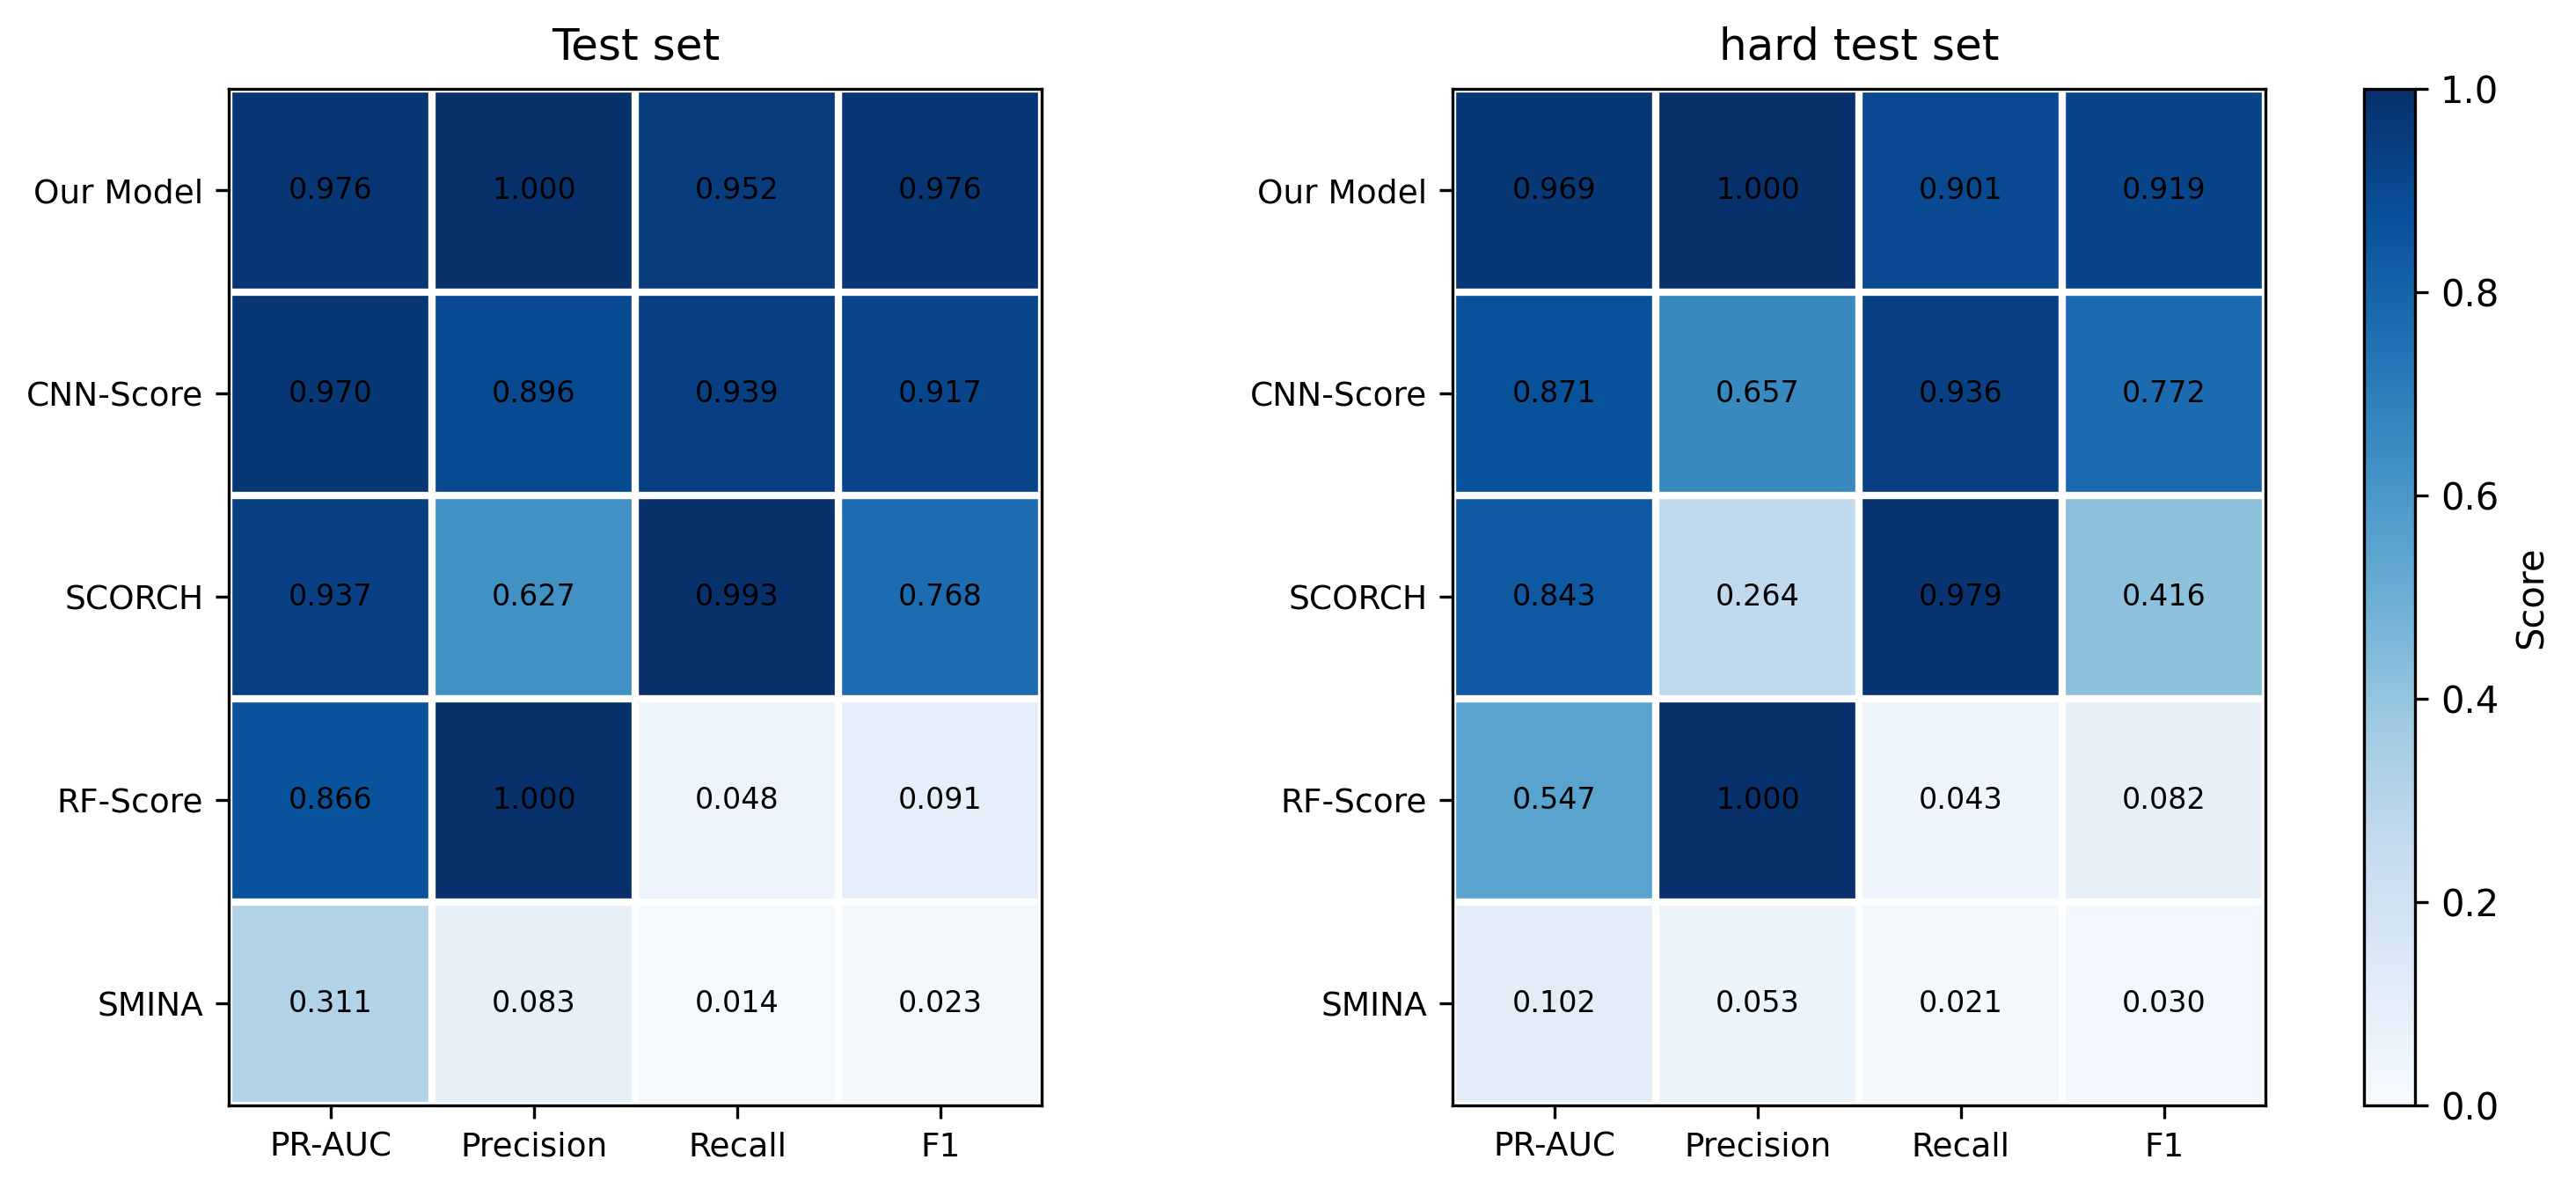

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# First dataset
# =========================
data1 = {
    "PR-AUC":    [0.9760, 0.9702, 0.8661, 0.9374, 0.3112],
    "Precision": [1.0000, 0.8961, 1.0000, 0.6266, 0.0833],
    "Recall":    [0.9520, 0.9388, 0.0476, 0.9932, 0.0136],
    "F1":        [0.9756, 0.9169, 0.0909, 0.7684, 0.0234],
}
models = ["Our Model", "CNN-Score", "RF-Score", "SCORCH", "SMINA"]
df1 = pd.DataFrame(data1, index=models).sort_values("PR-AUC", ascending=False)

# =========================
# Second dataset
# =========================
data2 = {
    "PR-AUC":    [0.969,  0.8706, 0.5472, 0.8431, 0.1023],
    "Precision": [1.000,  0.6567, 1.0000, 0.2644, 0.0526],
    "Recall":    [0.9010, 0.9362, 0.0426, 0.9787, 0.0213],
    "F1":        [0.9195, 0.7719, 0.0816, 0.4163, 0.0303],
}
df2 = pd.DataFrame(data2, index=models).sort_values("PR-AUC", ascending=False)

# =========================
# Heatmap function
# =========================
def plot_heatmap(ax, df, title):
    im = ax.imshow(df.values, cmap="Blues", vmin=0, vmax=1)

    # Ticks & labels
    ax.set_xticks(np.arange(df.shape[1]))
    ax.set_yticks(np.arange(df.shape[0]))
    ax.set_xticklabels(df.columns, fontsize=9)
    ax.set_yticklabels(df.index, fontsize=9)

    # Grid
    ax.set_xticks(np.arange(-.5, df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate values
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            val = df.iat[i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    color="black", fontsize=8)

    ax.set_title(title, fontsize=12, pad=8)
    return im

# =========================
# Choose layout: 1×2 or 2×1
# =========================
layout = "1x2"   # change to "2x1" for vertical

if layout == "1x2":
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)
else:
    fig, axes = plt.subplots(2, 1, figsize=(6, 9), dpi=300)

# Plot heatmaps
im1 = plot_heatmap(axes[0], df1, "Test set")
im2 = plot_heatmap(axes[1], df2, "hard test set")

# Shared colorbar
cbar = fig.colorbar(im1, ax=axes, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Score", fontsize=10)

# plt.tight_layout()
fig.patch.set_facecolor("white")

# ===== Save =====
# save_path = "/home/juni/working/mettl3/notebooks/attention_score/figures/figure_6"
# plt.savefig(f"{save_path}.tif", dpi=300, format="tiff",
#             pil_kwargs={"compression": "tiff_lzw"}, bbox_inches="tight")
# plt.savefig(f"{save_path}.png", dpi=300, format="png", bbox_inches="tight")

plt.show()
